***

* [总目录](../0_Introduction/0_introduction.ipynb)
* [术语表](../0_Introduction/1_glossary.ipynb)
* [5. 成像](5_0_introduction.ipynb)
    * 上一节： [5.3 FFT 中的网格化与去网格化](5_3_gridding_and_degridding.ipynb)
    * 下一节： [5.5 小角近似的失效与 w 项](5_5_widefield_effect.ipynb)

***


导入标准模块:

In [ ]:
import sys
from pathlib import Path

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
from scipy import signal

try:
    from IPython.display import HTML, Image, Javascript
except ImportError:
    def HTML(*args, **kwargs):
        return None

    def Image(*args, **kwargs):
        return None

    def Javascript(*args, **kwargs):
        return None

NOTEBOOK_DIR = Path("5_Imaging") if Path("5_Imaging").exists() else Path(".")
NOTEBOOK_DIR = NOTEBOOK_DIR.resolve()
FIGURE_DIR = NOTEBOOK_DIR / "figures"
TOGGLE_PATH = NOTEBOOK_DIR.parent / "style" / "code_toggle.html"

if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.append(str(NOTEBOOK_DIR))


def show_image(name, **kwargs):
    return Image(filename=str(FIGURE_DIR / name), **kwargs)

导入本节所需的专用模块:

In [ ]:
# The weighting demos in this chapter are designed to be self-contained,
# so no optional plotting or FITS dependencies are required here.

In [ ]:
if TOGGLE_PATH.exists():
    HTML(TOGGLE_PATH.read_text(encoding="utf-8"))

## 5.4 脏图像与可见度权重 <a id='imaging:sec:weights'></a>


到目前为止，我们已经介绍了空间滤波器、采样、点扩散函数，以及为了使用快速傅里叶变换而引入的网格化等概念。现在可以把这些内容串联起来，看看如何从一次射电干涉阵观测中生成图像。

所谓“脏图像”（dirty image）之所以这样命名，是为了与下一章将讨论的去卷积结果相区分。对一次观测而言，脏图像可以近似写成：


$$ I^{\textrm{D}}(l,m) \approx \int_{-\infty}^{\infty} \int_{-\infty}^{\infty} S(u,v) \, V_{\textrm{obs}}(u,v) \, e^{-2\pi i(ul+vm)} \,du\,dv $$

其中，$V_{\textrm{obs}}(u,v)$ 表示 $uv$ 空间中完整且连续的观测可见度函数；$S(u,v)$ 是采样函数，其主要组成部分是各条基线轨迹在 $uv$ 平面上的覆盖。

这个表达式只是一个近似式，因为在应用 [van Cittert-Zernike 定理 &#10142;](../4_Visibility_Space/4_5_The_Fourier_Approximation_VanCittert-Zernike_Theorem.ipynb) 时，我们把完整的三维可见度方程近似成了二维形式。下一节会继续讨论这种近似的局限，以及如何修正其中缺失的 $w$ 项。

在前一节关于网格化的讨论中我们已经看到，采样函数 $S$ 包含了 $uv$ 轨迹采样以及网格化算子。本节稍后还会进一步把采样函数推广为包含多种“权重”函数的更一般形式。于是，采样后的可见度可写为：


$$ V^{\textrm{S}} = S(u,v) \, V_{\textrm{obs}}(u,v) $$

上式把所有基线的可见度采样整合到了同一个可见度平面上。对照 [5.1 &#10142;](5_1_spatial_frequencies.ipynb) 中的二维傅里叶变换可以看出，脏图像就是采样可见度的傅里叶变换。


$$ I^{\textrm{D}} = \mathscr{F}\{V^{\textrm{S}}\} = \mathscr{F}\{ S V_{\textrm{obs}}\}$$

为简洁起见，这里省略了 $(l,m)$ 与 $(u,v)$ 的显式记号。根据傅里叶理论（见[$\S$ 2.5 &#10142;](../2_Mathematical_Groundwork/2_5_convolution.ipynb)），脏图像可以理解为两个函数在图像域中的卷积。


$$ I^{\textrm{D}} = \mathscr{F}\{ S \} \circ \mathscr{F}\{ V_{\textrm{obs}}\}$$

其中，第一个函数 $\mathscr{F}\{ S \}$ 是阵列的 PSF 响应，它依赖于阵列构型、天空位置、观测时长以及频率覆盖范围（见 [5.2 &#10142;](5_2_sampling_functions_and_psfs.ipynb)）。第二个函数 $\mathscr{F}\{ V_{\textrm{obs}}\}$ 则对应于完整采样可见度空间后的傅里叶变换。

现实中我们永远无法真正获得完整的 $V_{\textrm{obs}}$，但在[下一章 &#10142;](../6_Deconvolution/6_0_introduction.ipynb)会看到，我们可以结合先验信息并通过对 PSF 做去卷积，重建出一个近似的 $V_{\textrm{obs}}$。因此，也可以把 $\mathscr{F}\{ V_{\textrm{obs}}\}$ 看作由完整采样可见度平面所恢复出的理想图像 $I^{\textrm{ideal}}$。于是脏图像公式可进一步写为：


$$ I^{\textrm{D}} = \textrm{PSF} \circ I^{\textrm{ideal}}$$

回到前面的示例，我们可以利用 [5.2 &#10142;](5_2_sampling_functions_and_psfs.ipynb) 中某次 KAT-7 观测的 PSF 响应，对原始鸭子图像生成一幅脏图像。


In [ ]:
duck = mpimg.imread(str(FIGURE_DIR / 'Anas_platyrhynchos_male_female_quadrat_512.png'))


def rgb2gray(rgb):
    r, g, b = rgb[:, :, 0], rgb[:, :, 1], rgb[:, :, 2]
    gray = 0.2989 * r + 0.5870 * g + 0.1140 * b
    return gray


gDuck = rgb2gray(duck)
fftDuck = np.fft.fftshift(np.fft.fft2(gDuck))

In [ ]:
rng = np.random.default_rng(2)
grid_n = gDuck.shape[0]
max_radius = 0.42 * grid_n
n_pairs = 5000
angles = rng.uniform(0.0, 2.0 * np.pi, n_pairs)
radii = max_radius * np.sqrt(rng.uniform(0.03, 1.0, n_pairs))
u = np.rint(radii * np.cos(angles)).astype(int)
v = np.rint(radii * np.sin(angles)).astype(int)
keep = (np.abs(u) < grid_n // 2 - 2) & (np.abs(v) < grid_n // 2 - 2)
u = u[keep]
v = v[keep]
coords = np.vstack([np.column_stack([u, v]), np.column_stack([-u, -v])])
center = grid_n // 2
samplingCounts = np.zeros((grid_n, grid_n), dtype=float)
np.add.at(samplingCounts, (coords[:, 1] + center, coords[:, 0] + center), 1.0)
sampFunc = samplingCounts / samplingCounts.max()

In [ ]:
fig, axes = plt.subplots(figsize=(16, 8))

ax1 = plt.subplot(1, 2, 1)
fftDirtyImg = sampFunc * fftDuck
dirtyImg = np.abs(np.fft.ifft2(np.fft.ifftshift(fftDirtyImg)))
plt.title('Duck (dirty image)')
imgPlot0 = plt.imshow(dirtyImg)
imgPlot0.set_cmap('gray')

ax2 = plt.subplot(1, 2, 2)
plt.title('Duck (model image)')
imgPlot1 = plt.imshow(gDuck)
imgPlot1.set_cmap('gray')

*图：鸭子脏图像（左）与原始鸭子图像（右）。采样所用的是 KAT-7 在赤纬 -30 度方向上、持续 6 小时、包含 100 个频率通道的一次观测。*


从上面的脏图像中很难直接辨认出鸭子的形状。之所以还能看出头部和长翅膀，很大程度上是因为我们已经知道原始图像长什么样。如果事先不知道原图，那么仅凭这幅脏图往往很难判断其中的真实结构。

这正是干涉测量成像中的核心困难之一，也推动了各种去卷积算法的发展。

下图给出了 KAT-7 的 PSF 的傅里叶变换，它应当与 [5.2 &#10142;](5_2_sampling_functions_and_psfs.ipynb) 中看到的 $uv$ 覆盖图相近。确实如此，但请注意色条反映出像素值有明显范围，这说明不同位置的采样权重并不完全相同。这又回到了前面提到的 $uv$ 轨迹重叠以及生成 PSF 时所采用的权重方案。此前我们为了便于理解，暂时忽略了这些细节；接下来，就要把权重函数正式纳入采样函数的讨论中。


In [ ]:
fig = plt.figure(figsize=(8, 8))
plt.title('Synthetic sampling function')
imgPlot = plt.imshow(np.fft.fftshift(sampFunc))
plt.colorbar()

*图：KAT-7 的采样函数，观测条件为 100 个频率通道、赤纬 -30 度、持续 6 小时。*


### 5.4.1 权重函数：采样函数的推广


采样函数（例如 [5.2 &#10142;](5_2_sampling_functions_and_psfs.ipynb) 中 KAT-7 的采样函数）由许多基线轨迹共同构成，因此在可见度域中既存在空洞，也存在重叠采样区域。到目前为止，我们往往把采样函数看成二值函数：某个可见度像素若被采样则取 1，否则取 0。未被采样的位置取 0 这一点很好理解，因为这些位置没有观测信息，其真实值理论上可能是什么都行。

但对已被采样的位置来说，采样函数的值并不一定非得是 1。例如，一次观测如果测得 1000 个 $uv$ 位置，其中有 100 个位置被重复测量了 10 次，而其余 900 个位置只测量 1 次，那么这 100 个位置相对于另外 900 个位置就拥有约 $\sqrt{10}$ 倍的灵敏度提升，因此在成图时也许就应给予更高权重。

此外，若阵列由多种不同性能的望远镜组成（例如 VLBI），则有些基线天然更灵敏，有些则更不灵敏；在这种情况下，高灵敏度基线的测量结果也应赋予更高权重。再比如，有时我们希望把点源从更大尺度的扩展气体结构中分离出来，这时就可能希望特别强调某些空间频率尺度。

因此，成图时通常需要在简单的二值采样函数之上引入更多调节因素。严格来说，并不存在唯一标准的“正确”权重方式，但在任何成图之前，都必须先定义所采用的权重函数。最常见的是密度权重函数，后面还会继续讨论锥化权重和可信度权重。


$$ \textrm{PSF}(l,m) \rightleftharpoons W(u,v)$$

把 $W$ 展开后可以看到，它是多个函数的乘积。本节采用 [<cite data-cite='1999ASPC..180.....T'>Synthesis Imaging in Radio Astronomy II</cite> &#10548;](http://adsabs.harvard.edu/abs/1999ASPC..180.....T) 第 7 讲中的记号，并为简洁起见省略 $(u,v)$ 变量。


$$ W = R \cdot T \cdot D \cdot S $$

$W$ 是以下几项的乘积：前面已经讨论过的采样函数 $S$、密度权重函数 $D$、可选的锥化权重函数 $T$，以及与基线相关的可靠性权重函数 $R$。

下面先看一个一维权重函数及其 PSF 响应的简单例子。假设我们只采样了一维函数的中心区域，那么对应的采样函数就是一个矩形窗，在图中用蓝色表示。若进一步认为某些样本“质量更高”，例如探测器对靠近零点的位置响应更强，那么就可以让越靠近中心的样本拥有越大的权重，于是得到图中的绿色三角权重函数。类似地，也可以选择高斯型权重函数，在图中用红色表示。

这些权重函数覆盖的是同一段采样范围，但产生的 PSF 却并不相同。右图显示，矩形权重函数（蓝色）给出最窄最强的主瓣，但也带来了更明显的旁瓣；高斯或三角权重虽然能降低旁瓣，却会让主瓣变宽，也就是损失一定分辨率。原因在于它们给中心附近、也就是低空间频率模式，更高的权重。


In [ ]:
from scipy import signal

whw = 48 #window half width

#Square/Boxcar weight function
squareWeights = np.zeros(512, dtype='float')
squareWeights[256 - whw:256 + whw] = 1.

#Triangle weight function
triWeights = np.zeros(512, dtype='float')
triWeights[256 - whw : 256] = np.linspace(0., 1., num=whw)
triWeights[256 : 256 + whw] = np.linspace(1., 0., num=whw)

#Gaussian weight function
gaussWeights = signal.windows.gaussian(512, std=whw / (2. * np.sqrt(2. * np.log(2.))))
truncGaussWeights = gaussWeights * squareWeights #truncate to window width

xVals = np.arange(-256,256)

fig, axes = plt.subplots(figsize=(16,8))
ax1 = plt.subplot(2,2,1)
plt.title('Weight Functions')
plt.ylabel('Weight')
plt.plot(xVals, squareWeights, 'b-', alpha=0.7)
plt.plot(xVals, triWeights, 'g-', alpha=0.7)
plt.plot(xVals, truncGaussWeights, 'r-', alpha=0.7)
#plt.plot(xVals, gaussWeights, 'k-', alpha=0.7)

ax1 = plt.subplot(2,2,2)
plt.title('PSF (dBs)')
plt.ylabel('Response')
plt.plot(np.abs(np.fft.fftshift(np.fft.fft(squareWeights))), 'b-', alpha=0.7)
plt.plot(np.abs(np.fft.fftshift(np.fft.fft(triWeights))), 'g-', alpha=0.7)
plt.plot(np.abs(np.fft.fftshift(np.fft.fft(truncGaussWeights))), 'r-', alpha=0.7)
#plt.plot(np.abs(np.fft.fftshift(np.fft.fft(gaussWeights))), 'k-', alpha=0.7)
ax1.set_yscale('log')
plt.xlim(0, 512)

ax1 = plt.subplot(2,2,3)
plt.title('Weight Functions')
plt.ylabel('Weight')
plt.plot(xVals, gaussWeights, 'k-', alpha=0.7)
plt.plot(xVals, truncGaussWeights, 'r-', alpha=1.0)

ax1 = plt.subplot(2,2,4)
plt.title('PSF (dBs)')
plt.ylabel('Response')
plt.plot(np.abs(np.fft.fftshift(np.fft.fft(gaussWeights))), 'k-', alpha=0.7)
plt.plot(np.abs(np.fft.fftshift(np.fft.fft(truncGaussWeights))), 'r-', alpha=0.7)
ax1.set_yscale('log')
plt.xlim(0, 512)

*上图：若干一维权重函数及其对应的 PSF 响应。蓝色为矩形权重函数，绿色为三角权重函数，红色为截断高斯权重函数。*

*下图：高斯权重（黑色）与截断高斯权重（红色）及其 PSF 响应。高斯响应中极低幅度的“噪声”来自数值计算精度限制。*


上图只展示了三种可能的权重函数及其 PSF 响应。它们都不是“唯一正确”的选择，而是各有优缺点。矩形函数能够最大化 PSF 主瓣响应，但代价是较强的旁瓣；三角函数能较好压低旁瓣，但会损失部分信号强度和分辨率；高斯函数也有类似取舍。

这种分辨率损失，也就是主瓣变宽，本质上是因为权重函数把更多权重给了中心附近的低空间频率模式。

后面会看到，在实际成图时，我们正是根据科学目标来选择合适的权重函数，例如更强调分辨率、更强调灵敏度，或者在两者之间折中。


### 5.4.2 密度函数


在讨论、报告或论文里，人们提到“权重函数”时，很多时候实际上指的就是“密度权重函数”。密度权重函数根据某个 $uv$ 位置在观测中被采样的次数，为该位置设置权重。文献中常见的“统一权重”（uniform weighting）和“自然权重”（natural weighting）都属于密度权重函数。

回到前面展示的示意采样函数，我们会发现其中像素值并不是只有 0 或 1，而是落在某个范围内。这是因为在实际观测中，频率带宽覆盖以及 $uv$ 轨迹之间的重叠，会使某些可见度像素被采样多次。在生成 PSF 时，如果我们让每一次采样都拥有相同的单次权重，那么最终这些位置的总权重就会不同，表现为采样函数像素值存在范围变化。

这种方式与上一节一维示例里的高斯型权重有些相似。它被称为“自然权重”，也常被称为“逆方差权重”。它的优点是能最大化灵敏度，缺点则是会牺牲一定分辨率。文献中常说自然权重会让 PSF 的主瓣“长出更宽的翼部”，本质上就是因为低空间频率区域被重复采样得更密、更重。

$$ D_{\textrm{natural}}(u,v) = N_s(u,v)$$

统一权重函数可写为：


$$ D_{\textrm{uniform}}(u,v \, | \, t) = 
\begin{cases}
    1 & N_s(u,v) > t \\
    0 & N_s(u,v) \leq t
\end{cases}
$$

其中 $t$ 是一个非负阈值参数，通常取 $t = 0$。


具体选择哪种权重方案取决于观测的科学目标。如果你想尽可能提高分辨率，并愿意牺牲一部分灵敏度，那么通常选择统一权重；如果观测对象较弱，更看重灵敏度而愿意接受较低分辨率，那么自然权重会更合适。下面用一个可重复的模拟覆盖实验来展示：在同一片天空模型下，自然权重与统一权重会给出怎样不同的 PSF 和脏图像。

In [ ]:
import collections


def make_synthetic_sky(grid_size, field_size_deg):
    axis = (np.arange(grid_size) - grid_size / 2) * (field_size_deg / grid_size)
    ll, mm = np.meshgrid(axis, axis)
    sky = (
        1.00 * np.exp(-((ll + 0.22) ** 2 + (mm - 0.10) ** 2) / (2 * 0.04 ** 2))
        + 0.55 * np.exp(-((ll - 0.08) ** 2 + (mm + 0.18) ** 2) / (2 * 0.07 ** 2))
    )
    for l0, m0, flux in [(0.26, -0.24, 0.30), (-0.31, 0.24, 0.22), (0.08, 0.02, 0.15)]:
        ix = np.argmin(np.abs(axis - l0))
        iy = np.argmin(np.abs(axis - m0))
        sky[iy, ix] += flux
    return axis, sky



def build_weighting_case(grid_size=128, field_size_deg=1.4, coverage='even', noise_scale=0.015, seed=0):
    rng = np.random.default_rng(seed)
    axis, true_sky = make_synthetic_sky(grid_size, field_size_deg)
    vis_grid = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(true_sky)))
    max_radius = 0.46 * grid_size
    n_pairs = 1800 if coverage == 'even' else 2600
    angles = rng.uniform(0.0, 2.0 * np.pi, n_pairs)
    if coverage == 'even':
        radii = max_radius * np.sqrt(rng.uniform(0.05, 1.0, n_pairs))
    else:
        n_core = int(0.72 * n_pairs)
        core = max_radius * 0.22 * np.sqrt(rng.uniform(0.0, 1.0, n_core))
        tail = max_radius * np.sqrt(rng.uniform(0.15, 1.0, n_pairs - n_core))
        radii = np.concatenate([core, tail])
        rng.shuffle(radii)
    u = np.rint(radii * np.cos(angles)).astype(int)
    v = np.rint(radii * np.sin(angles)).astype(int)
    keep = (np.abs(u) < grid_size // 2 - 2) & (np.abs(v) < grid_size // 2 - 2) & ((u != 0) | (v != 0))
    coords_half = np.column_stack([u[keep], v[keep]])
    coords = np.vstack([coords_half, -coords_half])
    center = grid_size // 2
    density = np.zeros((grid_size, grid_size), dtype=float)
    np.add.at(density, (coords[:, 1] + center, coords[:, 0] + center), 1.0)
    signal_samples = vis_grid[coords[:, 1] + center, coords[:, 0] + center]
    noise = noise_scale * (rng.normal(size=coords.shape[0]) + 1j * rng.normal(size=coords.shape[0]))
    vis_samples = signal_samples + noise
    return {
        'grid_size': grid_size,
        'field_size_deg': field_size_deg,
        'axis': axis,
        'true_sky': true_sky,
        'vis_grid': vis_grid,
        'coords': coords,
        'density': density,
        'vis_samples': vis_samples,
        'center': center,
    }



def make_density_weights(case, mode='natural', robust=0.0):
    density_lookup = case['density'][case['coords'][:, 1] + case['center'], case['coords'][:, 0] + case['center']]
    if mode == 'natural':
        return np.ones_like(density_lookup)
    if mode == 'uniform':
        return 1.0 / density_lookup
    avg_density = np.mean(case['density'][case['density'] > 0])
    f2 = (5.0 * 10.0 ** (-robust)) ** 2 / avg_density
    return 1.0 / (1.0 + density_lookup * f2)



def make_dirty_products(case, weights):
    n = case['grid_size']
    c = case['center']
    weighted_sampling = np.zeros((n, n), dtype=float)
    weighted_vis = np.zeros((n, n), dtype=complex)
    np.add.at(weighted_sampling, (case['coords'][:, 1] + c, case['coords'][:, 0] + c), weights)
    np.add.at(weighted_vis, (case['coords'][:, 1] + c, case['coords'][:, 0] + c), weights * case['vis_samples'])
    psf = np.real(np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(weighted_sampling))))
    dirty = np.real(np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(weighted_vis))))
    psf_peak = np.max(psf)
    return {
        'sampling': weighted_sampling / weighted_sampling.max(),
        'psf': psf / psf_peak,
        'dirty': dirty / psf_peak,
    }


case_even = build_weighting_case(coverage='even', seed=10)
case_core = build_weighting_case(coverage='core', seed=24, noise_scale=0.02)

case_even_products = {
    'natural': make_dirty_products(case_even, make_density_weights(case_even, 'natural')),
    'uniform': make_dirty_products(case_even, make_density_weights(case_even, 'uniform')),
    'robust0': make_dirty_products(case_even, make_density_weights(case_even, 'briggs', robust=0.0)),
}
case_core_products = {
    'natural': make_dirty_products(case_core, make_density_weights(case_core, 'natural')),
    'uniform': make_dirty_products(case_core, make_density_weights(case_core, 'uniform')),
    'robust0': make_dirty_products(case_core, make_density_weights(case_core, 'briggs', robust=0.0)),
}

robust_values = [2.0, 1.0, 0.5, 0.0, -0.5, -1.0, -2.0]
robust_even_psf = collections.OrderedDict()
robust_core_psf = collections.OrderedDict()
for robust in robust_values:
    robust_even_psf[robust] = make_dirty_products(case_even, make_density_weights(case_even, 'briggs', robust=robust))['psf']
    robust_core_psf[robust] = make_dirty_products(case_core, make_density_weights(case_core, 'briggs', robust=robust))['psf']

fig = plt.figure(figsize=(8, 8))
plt.title('True sky')
imgPlot = plt.imshow(
    case_even['true_sky'],
    cmap='viridis',
    origin='lower',
    extent=[case_even['axis'][0], case_even['axis'][-1], case_even['axis'][0], case_even['axis'][-1]],
)
plt.xlabel('l (deg)')
plt.ylabel('m (deg)')
plt.colorbar(imgPlot)

*图：模拟天空图。图中的亮斑包含点源与展宽结构，因此既能观察分辨率变化，也能观察旁瓣和噪声在不同权重下的表现。*

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
img_extent = [case_even['axis'][0], case_even['axis'][-1], case_even['axis'][0], case_even['axis'][-1]]
psf_extent = [-case_even['grid_size'] / 2, case_even['grid_size'] / 2, -case_even['grid_size'] / 2, case_even['grid_size'] / 2]

axes[0, 0].imshow(case_even_products['natural']['psf'], origin='lower', extent=psf_extent, cmap='viridis')
axes[0, 0].set_title('PSF (natural weighting)')
axes[0, 0].set_xlabel('l pixel')
axes[0, 0].set_ylabel('m pixel')

axes[0, 1].imshow(case_even_products['uniform']['psf'], origin='lower', extent=psf_extent, cmap='viridis')
axes[0, 1].set_title('PSF (uniform weighting)')
axes[0, 1].set_xlabel('l pixel')
axes[0, 1].set_ylabel('m pixel')

axes[1, 0].imshow(case_even_products['natural']['dirty'], origin='lower', extent=img_extent, cmap='viridis')
axes[1, 0].set_title('Dirty image (natural weighting)')
axes[1, 0].set_xlabel('l (deg)')
axes[1, 0].set_ylabel('m (deg)')

axes[1, 1].imshow(case_even_products['uniform']['dirty'], origin='lower', extent=img_extent, cmap='viridis')
axes[1, 1].set_title('Dirty image (uniform weighting)')
axes[1, 1].set_xlabel('l (deg)')
axes[1, 1].set_ylabel('m (deg)')

plt.tight_layout()

center = case_even['center']
for key in ['natural', 'uniform', 'robust0']:
    psf_slice = case_even_products[key]['psf'][center]
    beam_width = np.sum(psf_slice > 0.5)
    residual = case_even_products[key]['dirty'] - case_even['true_sky']
    background_rms = np.std(residual[np.abs(case_even['true_sky']) < 0.05])
    print(f"{key:8s} | half-power beam width = {beam_width:2d} pixels | background RMS = {background_rms:.4f}")

*上：同一组较均匀 $uv$ 覆盖在自然权重（左）与统一权重（右）下得到的 PSF。*

*下：基于同一模拟天空生成的脏图像，自然权重在左，统一权重在右。可以看到两者在主瓣宽度、旁瓣水平和背景噪声上存在明显折中。*

与统一权重相比，自然权重图像中的源会显得更大，这是因为自然权重对应的 PSF 主瓣更宽。统一权重图像则会在源周围出现更明显的振铃，这是由于统一权重的 PSF 更接近 sinc 形状，因此其旁瓣比自然权重的 PSF 更尖锐、负旁瓣也更明显。


Daniel Briggs 在论文 [<cite data-cite='briggs1995high'>High Fidelity Deconvolution of Moderately Resolved Sources</cite> &#10548;](http://www.aoc.nrao.edu/dissertations/dbriggs/) 中提出了一种可调参数的密度权重函数。核心思想是：自然权重和统一权重并不是两个彼此割裂的方案，而是同一连续谱上的两个端点，这个连续变化由单一参数“鲁棒性”来控制。

因此，这种推广后的权重方式称为“鲁棒权重”（robust weighting），也常被称作 Briggs 权重。参数 $R$ 的两个极端分别逼近自然权重和统一权重，而 $R=0$ 左右则代表分辨率与图像方差之间的一种折中平衡。不同成图器对鲁棒权重的具体实现细节可能略有不同，但总体效果应当类似。


In [ ]:
fig = plt.figure(figsize=(16, 6))
center = case_even['center']
window = slice(center - 26, center + 27)

for key in ['natural', 2.0, 1.0, 0.5, 0.0, -0.5, -1.0, -2.0, 'uniform']:
    if key == 'natural':
        psf_slice = case_even_products['natural']['psf'][center, window]
        color = [1.0, 0.0, 0.0]
        label = 'natural'
    elif key == 'uniform':
        psf_slice = case_even_products['uniform']['psf'][center, window]
        color = [0.0, 1.0, 0.0]
        label = 'uniform'
    else:
        psf_slice = robust_even_psf[key][center, window]
        norm = (float(key) + 2.0) / 4.0
        color = [norm, 1.0 - norm, 0.0]
        label = str(key)
    plt.plot(psf_slice, label=label, color=color)

plt.title('PSF cross-section (moderately even coverage)')
plt.xlim(0, len(psf_slice) - 1)
plt.legend()

*图：一个较均匀覆盖示例在自然权重、统一权重以及一系列鲁棒权重下的 PSF 截面。自然权重（红色）具有较小的旁瓣幅度，但主瓣更宽；统一权重（绿色）主瓣最窄，但旁瓣更强；鲁棒权重允许通过参数连续调节主瓣分辨率与旁瓣水平之间的折中。当鲁棒度为 -2 时，结果大致接近统一权重；当鲁棒度为 2 时，则大致接近自然权重。*

如果某种权重函数更偏向于优待在观测中被过度采样的可见度样本，那么它就更接近自然权重；反之，如果更强调采样较少的位置，则更接近统一权重。因此，正的鲁棒参数通常意味着结果更像自然权重，负的鲁棒参数则更像统一权重。

当 $R=-2$ 时，鲁棒权重大致逼近统一权重；当 $R=2$ 时，则大致逼近自然权重。进一步地，鲁棒权重也允许 $|R| > 2$。若 $R>2$，就会进一步上调那些被高度重复采样的可见度（通常是较短基线），从而得到比自然权重更低的分辨率，但旁瓣更平滑，这在研究大尺度弥散结构时可能有利。若 $R<-2$，则会进一步提高采样稀少的可见度（通常是最长基线）的权重，从而获得比统一权重更高的分辨率，但代价是旁瓣更强；当视场中存在高信噪比源、希望尽量分辨其细节时，这类设置可能会有帮助。


当基线分布比较均匀时，密度权重函数的选择虽然重要，但差异通常还算温和；对于核心区域非常致密的阵列，例如 MeerKAT 阵列一期以及未来的 SKA-MID，这种选择就会变得十分关键。因为这类阵列的大量基线集中在低空间频率区域，等价于对那一部分测量赋予了更高强调。此时若选择自然权重，源周围可能出现类似光晕的结构；而统一权重则会显著提高角分辨率。

In [ ]:
show_image("meerkat_AR1.png")

In [ ]:
show_image("meerkat_16hr_1.1ghz.png")

*图：MeerKAT 阵列一期的天线位置，以及它在 1.1 GHz、持续 6 小时观测条件下的 UV 覆盖。与 JVLA 和 KAT-7 相比，这一构型在中央区域明显更为致密。*


In [ ]:
fig = plt.figure(figsize=(16, 6))
center = case_core['center']
window = slice(center - 26, center + 27)

for robust in robust_values:
    psf_slice = robust_core_psf[robust][center, window]
    norm = (float(robust) + 2.0) / 4.0
    color = [norm, 1.0 - norm, 0.0]
    plt.plot(psf_slice, label=str(robust), color=color)

plt.plot(case_core_products['natural']['psf'][center, window], label='natural', color=[1.0, 0.0, 0.0], linewidth=2)
plt.plot(case_core_products['uniform']['psf'][center, window], label='uniform', color=[0.0, 1.0, 0.0], linewidth=2)
plt.title('PSF cross-section (dense-core coverage)')
plt.xlim(0, len(psf_slice) - 1)
plt.legend()

除统一权重、自然权重和鲁棒权重之外，还存在其他一些权重策略，例如适用于东西向阵列的径向权重，以及超统一权重（super-uniform）和亚统一权重（sub-uniform）。后两者的目的，是打破 PSF 对图像像素分辨率与视场大小的依赖。在成图时，像素分辨率和像素数量（也即视场）通常都是可调的，因此单个像素所代表的尺度会随参数变化而改变。分辨率较低的图像中，每个像素会包含更多可见度样本，于是即便使用相同权重函数，也可能得到不同的 PSF。超统一和亚统一权重通过为权重计算设定一个与图像分辨率无关的固定网格尺度，使不同分辨率、不同视场下的 PSF 更加一致。


### 5.4.3 锥函数


锥函数（taper function）可以看作比密度函数更一般的一类权重形式。之所以将它与密度函数分开讨论，是因为两者服务的目的不同：密度函数主要用于在分辨率和灵敏度之间取得平衡，而锥函数则更像作用于图像域的平滑滤波器。

干涉阵列测量的是一系列空间频率模式，但在很多情况下，我们只关心其中某个特定范围。例如，若已知目标源的大致尺度，或者我们并不关心把源解析得非常精细，而更关心尽量提高该源的信噪比，那么就可以采用锥函数。它本质上相当于针对特定信号的“匹配滤波器”，这一点与数字信号处理中的二维窗函数非常类似。

如果已知目标源的响应形状，那么选择与之匹配的锥函数，往往可以提高信噪比。本章的 [附录 A &#10142;](5_A_matched_filter.ipynb) 会继续讨论匹配滤波器在综合孔径成像中的用法。


尽管锥函数理论上可以是任意二维函数，但在实践中通常会选用平滑函数。最常见的是二维高斯，因为高斯的傅里叶变换仍然是高斯，这使得我们可以把图像域中设定的尺度方便地转换到可见度域中去，尽管振幅尺度还需要额外归一化。其他类型的锥函数可参考 [Wikipedia: Window Functions &#10548;](https://en.wikipedia.org/wiki/Window_function)。

若我们希望在图像域中用某个尺度来平滑图像，就可以用半高全宽为 $\theta_{\text{FWHM}}$ 的二维高斯来与图像做卷积：


$$ \text{Gauss}(l,m\, | \, \sigma_{I}) = e^{\frac{-(l^2 + m^2)}{2\sigma_{I}^2}}$$

$\sigma_{I}$ 表示图像域中该函数的标准差（这里假设采用径向对称的高斯），并满足 $\theta_{\text{FWHM}} = 2 \sqrt{2 \ln{2}}\sigma_{I}$。这是锥响应函数，它与可见度域中的锥函数互为傅里叶对。两者的尺度关系为 $\sigma_{uv} = \frac{1}{2\pi\sigma_{I}}$，其中 $\sigma_{uv}$ 的单位是波长数。于是，可见度域中的高斯锥函数（未归一化）可写为：


$$ \text{Gauss}(u,v\, | \, \sigma_{uv}) = e^{\frac{-(u^2 + v^2)}{2\sigma_{uv}^2}} = e^{\frac{-(u^2 + v^2) \pi^2 \theta_{\text{FWHM}}^2}{2 \ln{2}}}$$

Text(0.5,1,'Taper Function (uv domain)')

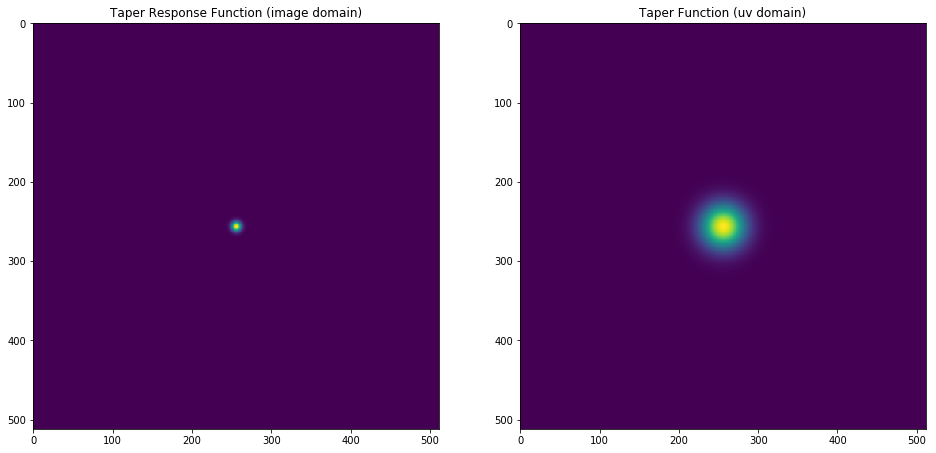

In [15]:
def gaussianTaperResponse(imSize, fwhmTheta):
    #Create an image-domain Gaussian taper response
    #imSize: [int, int] image size
    #fwhmTheta: full-width half-maximum in pixels
    lpos, mpos = np.mgrid[0:imSize[0],0:imSize[1]]
    sigma = fwhmTheta / (2. * np.sqrt(2. * np.log(2)))
    taper = np.exp(-1. * (((lpos - (imSize[0]/2.))**2. + (mpos - (imSize[1]/2.))**2.) / (2. * sigma**2.)))
    return taper

fig = plt.figure(figsize=(16, 8))

plt.subplot(121)
taperResponse = gaussianTaperResponse([512, 512], 10)
plt.imshow(taperResponse, cmap='viridis')
plt.title('Taper Response Function (image domain)')

plt.subplot(122)
taperedFunc = np.abs(np.fft.fftshift(np.fft.fft2(taperResponse)))
plt.imshow(taperedFunc, cmap='viridis')
plt.title('Taper Function (uv domain)')

*图：图像域中的高斯锥响应函数，与 $uv$ 域中的高斯锥函数构成一组傅里叶对。*


高斯锥函数可以理解为图像处理中的平滑滤波器。类似地，也可以设计更偏向锐化的锥函数，用于强调点源这类紧致目标。


In [ ]:
def convolveTaper(taperResponse, img):
    return np.fft.fftshift(np.fft.ifft2(np.fft.fft2(taperResponse) * np.fft.fft2(img))).real

img = case_core_products['uniform']['dirty']

fig = plt.figure(figsize=(16, 16))

plt.subplot(221)
taperResponse = gaussianTaperResponse(img.shape, 5)
taperedImg = convolveTaper(taperResponse, img)
plt.imshow(taperedImg, cmap='viridis', origin='lower')
plt.title('Dirty image (5 pixel taper)')

plt.subplot(222)
taperResponse = gaussianTaperResponse(img.shape, 10)
taperedImg = convolveTaper(taperResponse, img)
plt.imshow(taperedImg, cmap='viridis', origin='lower')
plt.title('Dirty image (10 pixel taper)')

plt.subplot(223)
taperResponse = gaussianTaperResponse(img.shape, 20)
taperedImg = convolveTaper(taperResponse, img)
plt.imshow(taperedImg, cmap='viridis', origin='lower')
plt.title('Dirty image (20 pixel taper)')

plt.subplot(224)
taperResponse = gaussianTaperResponse(img.shape, 40)
taperedImg = convolveTaper(taperResponse, img)
plt.imshow(taperedImg, cmap='viridis', origin='lower')
plt.title('Dirty image (40 pixel taper)')

*图：对 KAT-7 的统一权重脏图像施加不同尺度的锥函数。从左上开始按顺时针方向，锥函数宽度分别为 5、10、20、40 像素。*


从图中可以看出，原始脏图像的分辨率大约为 5 个像素，因此当施加 FWHM 同样约为 5 像素的高斯锥时（左上图），图像变化并不明显。但随着锥函数尺度增大，图像分辨率会逐渐下降，因为低空间频率模式相对于高空间频率模式被赋予了更高权重。

如果一个阵列拥有大量近似随机分布的天线，那么它得到的可见度采样分布往往会比较充分，并近似高斯分布。在这种情况下，给统一权重再乘上一个与该高斯采样分布尺度相当的锥函数，所得到的图像效果会与“不加锥函数的自然权重”非常接近。


### 5.4.4 测量可靠性函数


权重函数的最后一项是测量可靠性函数 $R(u,v)$。它与阵列本身以及具体观测条件密切相关。若阵列中的所有观测单元完全相同，那么各个可见度测量的相对可靠性也基本相同；但若某个单元系统温度较高（也就是更嘈杂），或者口径更小、灵敏度更低，那么所有包含该单元的基线都会得到噪声更大的相关测量，这一点就应当反映在权重中。诸如各天线的有效集光面积、预期系统温度等先验信息，都可以纳入该函数。观测过程中某些单元性能的临时变化，例如某台望远镜放大器异常偏噪，也同样应该体现在可靠性函数里。对 VLBI 这类混合阵列而言，各台望远镜灵敏度并不相同，因此尤其需要显式纳入这一项。如果原始观测没有给出这类可靠性权重，那么通常就把该函数取为 1 并忽略之。


### 5.4.5 脏图像的局限性


从前面展示的脏图像可以看到，源周围常会出现一些类似 PSF 旁瓣的结构。我们知道，这些结构并不属于真实天空，而是由可见度采样不充分以及测量系统本身带来的结果。于是自然会提出两个问题：第一，能否去掉这些旁瓣？第二，如果能去掉，会带来什么好处？

第二个问题的答案是：如果能压低较强的旁瓣，就有机会把原本被旁瓣掩盖的更弱源显露出来，相当于降低了图像的噪声底，也就是提高了动态范围。至于第一个问题，答案是可以在一定程度上通过去卷积方法，把测量过程施加到图像上的这部分结构去除掉。

“脏图像”这一术语是在综合成像早期发展、尤其是 CLEAN 等去卷积方法提出之后逐渐固定下来的。所谓去卷积，就是希望从观测可见度中恢复出一幅“更好”的图像。这里“更好”本身并没有一个完全客观统一的定义，但基本思想是明确的：脏图像中的亮源周围包围着由不规则采样带来的 PSF 型旁瓣，而这些并不是真实天体结构。若进一步假设真实天空在某种意义上是平滑或可描述的，那么即便只测得了部分可见度，我们仍可以借助这些合理假设，通过去卷积把图像恢复得更接近真实情况。下一章将专门展开这一主题。


不过，在介绍去卷积之前，我们还要先完成本章关于大视场成像的内容。节首给出的“脏图像与可见度”的关系式只是一个近似式，因为其中忽略了 $w$ 项，把原本的三维关系简化成了二维傅里叶变换。这种近似在窄视场条件下通常足够好，但对于视场更大、阵列尺度更大的观测，就必须显式考虑 $w$ 项。针对这一问题，已经发展出多种把偏离简单二维傅里叶关系的扰动有效纳入成像的方法。下一节将讨论的正是这些技术。


***

* 下一节： [5.5 小角近似的失效与 w 项](5_5_widefield_effect.ipynb)
